<a href="https://colab.research.google.com/github/Melyan16/Assignment1.datascience/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Dataset Loaded Successfully
   vehicle_speed  weather_condition  road_condition  driver_experience  \
0             40                  1               1                  5   
1             60                  2               2                 10   
2             80                  3               2                  2   
3             55                  1               1                  8   
4            100                  3               3                  1   

   accident_severity  
0                  2  
1                  3  
2                  4  
3                  2  
4                  5  

📊 Model Evaluation:
Mean Squared Error (MSE): 1.5722
R² Score: 0.0

💾 Model saved successfully as 'road_accident_severity_model.pkl'

🚗 Predicted Accident Severity for the Example Case: 4.38


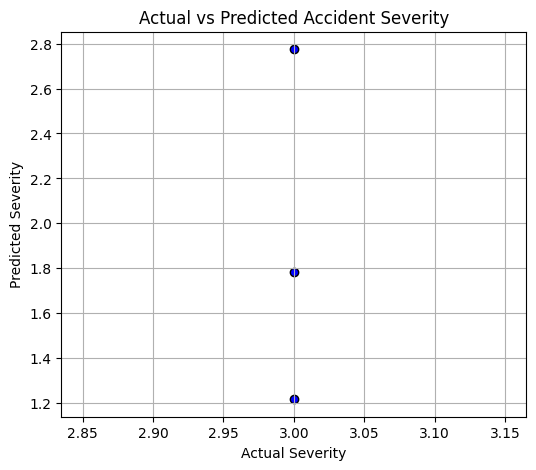


Dependent Variable: accident_severity (1–5 scale)
Independent Variables: vehicle_speed, weather_condition, road_condition, driver_experience

How this helps (especially in underdeveloped countries):
- Identifies risk factors contributing to severe accidents.
- Guides road-safety interventions (e.g., speed control, driver training).
- Enables resource prioritization for emergency response and prevention campaigns.



In [1]:
# ==============================
# 🚦 Road Accident Severity Analysis using Linear Regression
# Google Colab Complete Code Block
# ==============================

# --- Step 1: Install & import libraries
!pip install pandas numpy scikit-learn matplotlib joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# --- Step 2: Create or load dataset
# (Simulated dataset for demonstration)
data = {
    'vehicle_speed': [40, 60, 80, 55, 100, 70, 90, 120, 45, 85],
    'weather_condition': [1, 2, 3, 1, 3, 2, 3, 1, 2, 3],   # 1=Clear, 2=Rainy, 3=Foggy
    'road_condition': [1, 2, 2, 1, 3, 2, 3, 1, 2, 3],     # 1=Good, 2=Average, 3=Poor
    'driver_experience': [5, 10, 2, 8, 1, 6, 3, 12, 4, 2], # in years
    'accident_severity': [2, 3, 4, 2, 5, 3, 4, 5, 3, 4]   # Target variable (1–5)
}

df = pd.DataFrame(data)
print("✅ Dataset Loaded Successfully")
print(df.head())

# --- Step 3: Define dependent and independent variables
X = df[['vehicle_speed', 'weather_condition', 'road_condition', 'driver_experience']]
y = df['accident_severity']

# --- Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Step 5: Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# --- Step 6: Evaluate model
y_pred = model.predict(X_test)
print("\n📊 Model Evaluation:")
print("Mean Squared Error (MSE):", round(mean_squared_error(y_test, y_pred), 4))
print("R² Score:", round(r2_score(y_test, y_pred), 4))

# --- Step 7: Save the model for future use
joblib.dump(model, 'road_accident_severity_model.pkl')
print("\n💾 Model saved successfully as 'road_accident_severity_model.pkl'")

# --- Step 8: Predict severity for a hypothetical case
example = pd.DataFrame({
    'vehicle_speed': [95],
    'weather_condition': [2],   # Rainy
    'road_condition': [3],      # Poor
    'driver_experience': [4]    # 4 years experience
})

predicted = model.predict(example)
print("\n🚗 Predicted Accident Severity for the Example Case:", round(predicted[0], 2))

# --- Step 9: Visualization - Actual vs Predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, color='blue', edgecolors='black')
plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")
plt.title("Actual vs Predicted Accident Severity")
plt.grid(True)
plt.show()

# --- Step 10: Explanation Output
print("""
Dependent Variable: accident_severity (1–5 scale)
Independent Variables: vehicle_speed, weather_condition, road_condition, driver_experience

How this helps (especially in underdeveloped countries):
- Identifies risk factors contributing to severe accidents.
- Guides road-safety interventions (e.g., speed control, driver training).
- Enables resource prioritization for emergency response and prevention campaigns.
""")
